In [4]:
import struct
import numpy as np

def load_idx_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images

def load_idx_labels(path):
    with open(path, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

def rotate(images):
    images = np.array([np.rot90(np.fliplr(img)) for img in images])
    return images

train_images = load_idx_images('../data/original/emnist-byclass-train-images-idx3-ubyte')
train_labels = load_idx_labels('../data/original/emnist-byclass-train-labels-idx1-ubyte')
test_images = load_idx_images('../data/original/emnist-byclass-test-images-idx3-ubyte')
test_labels = load_idx_labels('../data/original/emnist-byclass-test-labels-idx1-ubyte')

train_images = rotate(train_images)
test_images = rotate(test_images)

mapping = {}
# Digits
for i in range(10):
    mapping[i] = str(i)

# Uppercase letters
for i in range(26):
    mapping[10 + i] = chr(65 + i)

# Lower letters
for i in range(26):
    mapping[36 + i] = chr(97 + i)


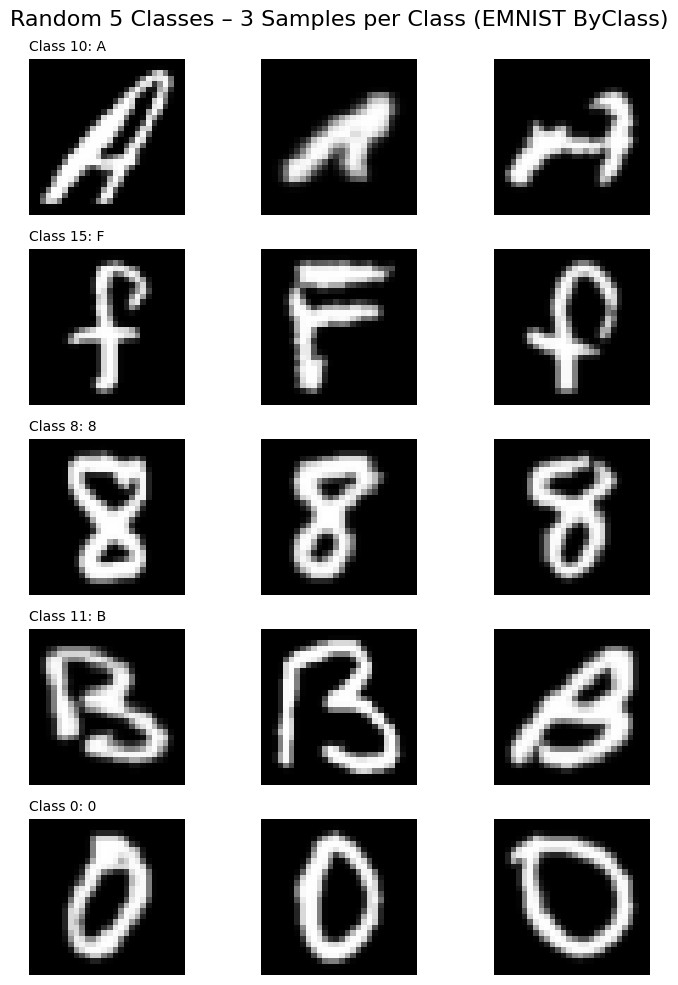

In [6]:
import matplotlib.pyplot as plt
import numpy as np

num_random_classes = 5
samples_per_class = 3

# chọn ngẫu nhiên 5 class khác nhau
random_classes = np.random.choice(
    np.unique(train_labels),
    size=num_random_classes,
    replace=False
)

fig, axes = plt.subplots(
    num_random_classes,
    samples_per_class,
    figsize=(samples_per_class * 2.5, num_random_classes * 2)
)

for i, c in enumerate(random_classes):
    idx = np.where(train_labels == c)[0]

    # chọn ngẫu nhiên 3 ảnh trong class đó
    chosen = np.random.choice(idx, size=samples_per_class, replace=False)

    for j in range(samples_per_class):
        ax = axes[i, j]
        ax.axis('off')
        ax.imshow(train_images[chosen[j]], cmap='gray')

        if j == 0:
            ax.set_title(
                f"Class {c}: {mapping[c]}",
                fontsize=10,
                loc='left'
            )

plt.suptitle(
    "Random 5 Classes – 3 Samples per Class (EMNIST ByClass)",
    fontsize=16
)

plt.tight_layout()
plt.show()


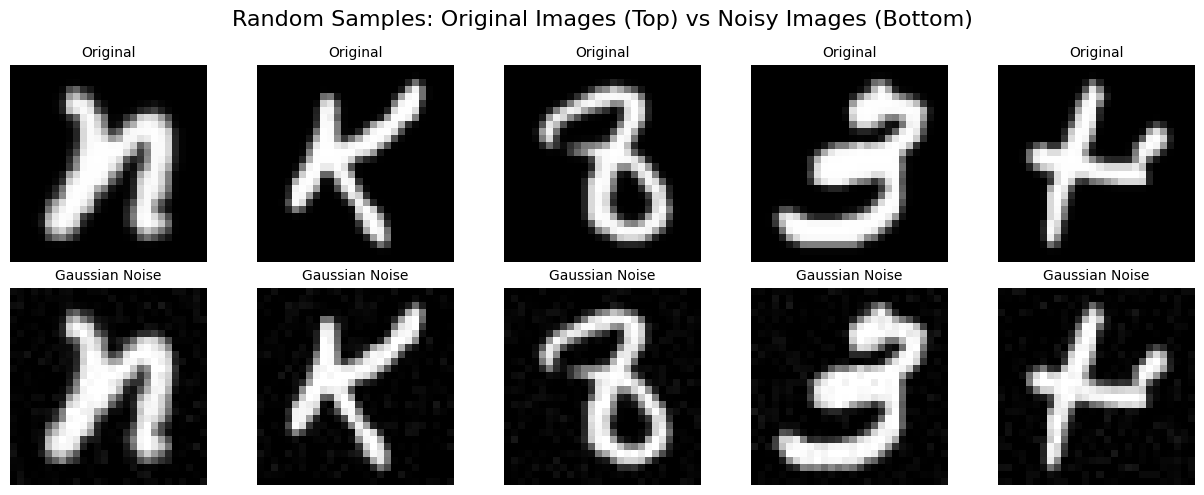

In [10]:
import matplotlib.pyplot as plt
import numpy as np

samples = 5
noise_std = 8  # Gaussian noise σ

# chọn ngẫu nhiên 5 ảnh bất kỳ
random_idx = np.random.choice(len(train_images), size=samples, replace=False)

fig, axes = plt.subplots(2, samples, figsize=(samples * 2.5, 5))

for i, idx in enumerate(random_idx):
    img = train_images[idx]

    # --- hàng trên: ảnh gốc ---
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title("Original", fontsize=10)

    # --- hàng dưới: ảnh sau nhiễu ---
    noise = np.random.normal(0, noise_std, img.shape)
    img_noisy = img + noise
    img_noisy = np.clip(img_noisy, 0, 255)

    axes[1, i].imshow(img_noisy, cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("Gaussian Noise", fontsize=10)

plt.suptitle(
    "Random Samples: Original Images (Top) vs Noisy Images (Bottom)",
    fontsize=16
)

plt.tight_layout()
plt.show()


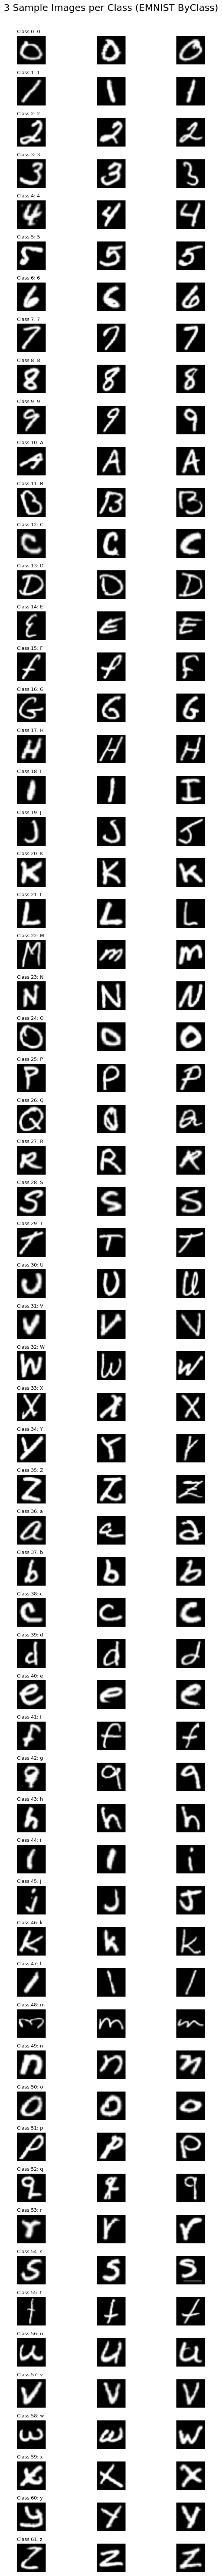

In [7]:
import matplotlib.pyplot as plt
import numpy as np

num_classes = 62
samples_per_class = 3

fig, axes = plt.subplots(
    num_classes,
    samples_per_class,
    figsize=(samples_per_class * 2.5, num_classes * 1.1)
)

for c in range(num_classes):
    idx = np.where(train_labels == c)[0]

    chosen = idx[:samples_per_class]

    for j in range(samples_per_class):
        ax = axes[c, j]
        ax.axis('off')

        if j < len(chosen):
            ax.imshow(train_images[chosen[j]], cmap='gray')

        if j == 0:
            ax.set_title(
                f"Class {c}: {mapping[c]}",
                fontsize=9,
                loc='left'
            )

plt.suptitle(
    "3 Sample Images per Class (EMNIST ByClass)",
    fontsize=18,
    y=1.002
)

plt.tight_layout()
plt.show()


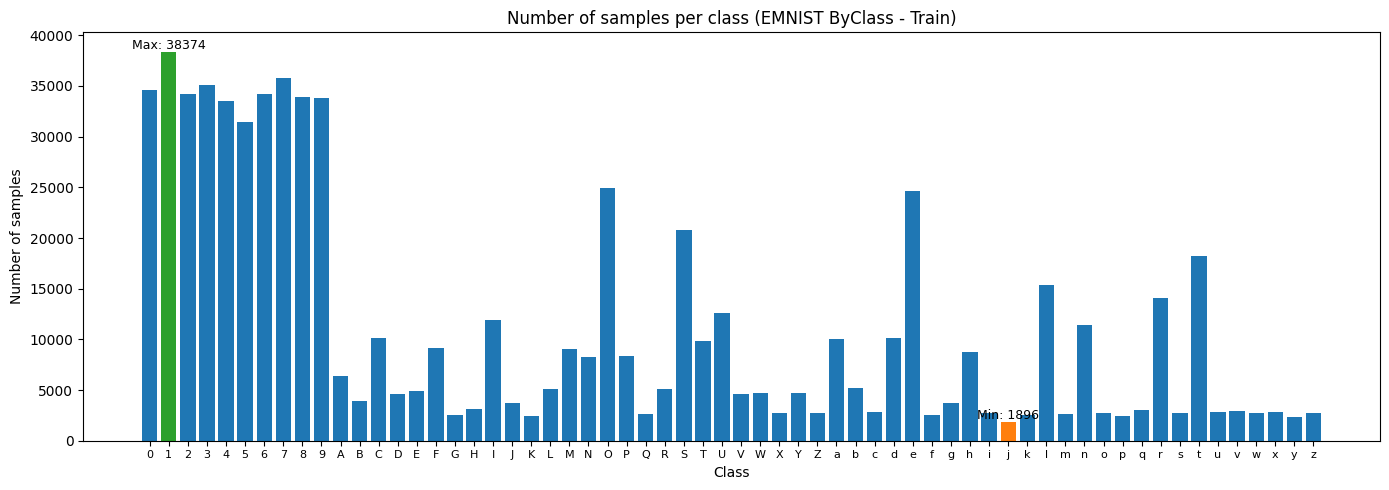

In [8]:
import numpy as np
import matplotlib.pyplot as plt

classes, counts = np.unique(train_labels, return_counts=True)

min_idx = np.argmin(counts)
max_idx = np.argmax(counts)

plt.figure(figsize=(14, 5))

plt.bar(classes, counts)
plt.bar(classes[min_idx], counts[min_idx])
plt.bar(classes[max_idx], counts[max_idx])

plt.xticks(classes, [mapping[c] for c in classes], fontsize=8)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Number of samples per class (EMNIST ByClass - Train)")

plt.text(classes[min_idx], counts[min_idx],
         f"Min: {counts[min_idx]}",
         ha='center', va='bottom', fontsize=9)

plt.text(classes[max_idx], counts[max_idx],
         f"Max: {counts[max_idx]}",
         ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


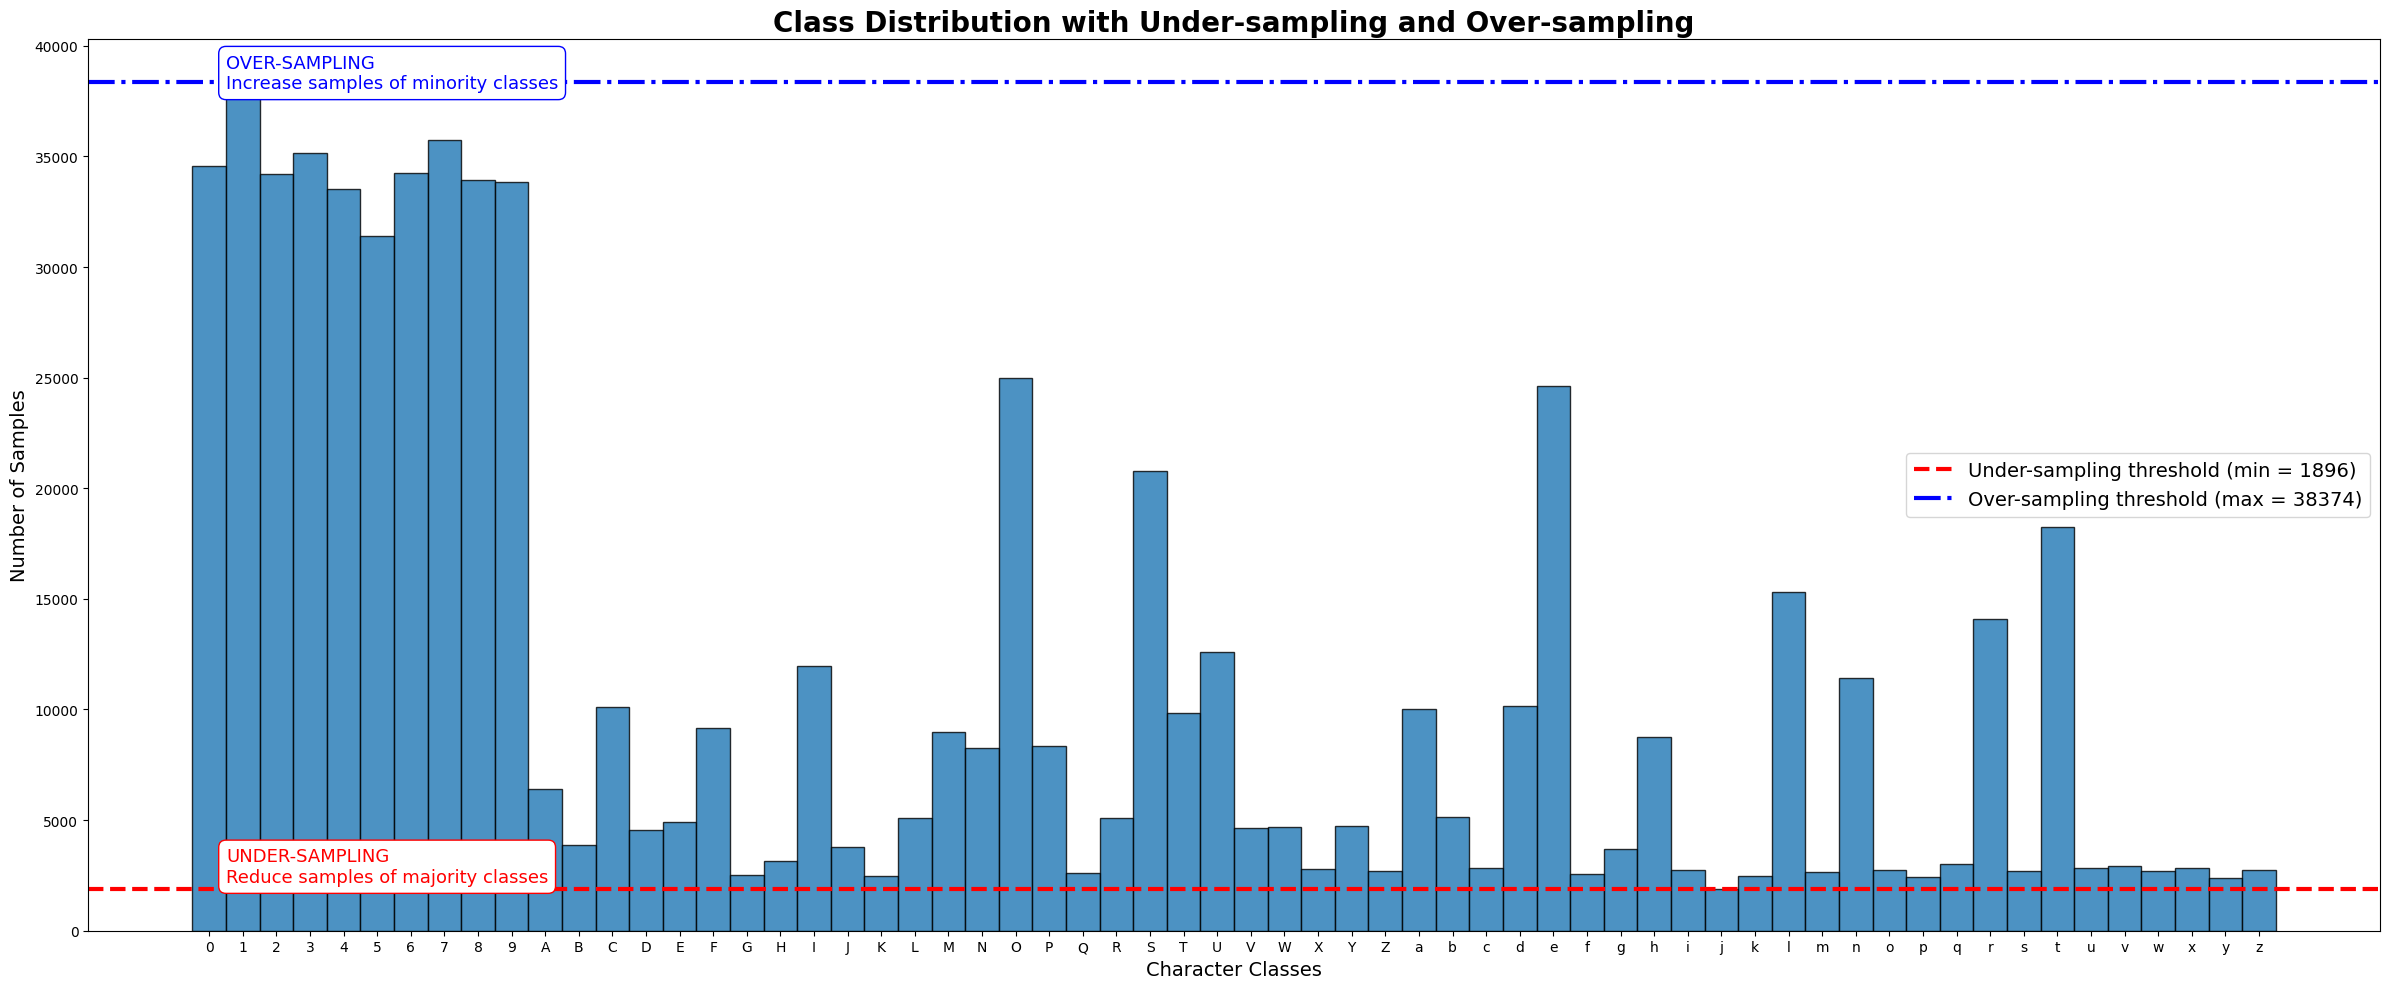

In [14]:
import matplotlib.pyplot as plt
import numpy as np

classes, class_counts = np.unique(train_labels, return_counts=True)

under_level = class_counts.min()
over_level = class_counts.max()

fig, ax = plt.subplots(figsize=(24, 10))

bins = np.arange(63) - 0.5
ax.hist(
    train_labels,
    bins=bins,
    edgecolor='black',
    alpha=0.8
)

ax.set_xticks(range(62))
ax.set_xticklabels(mapping.values())
ax.set_xlabel('Character Classes', fontsize=14)
ax.set_ylabel('Number of Samples', fontsize=14)

ax.set_title(
    'Class Distribution with Under-sampling and Over-sampling',
    fontsize=20,
    fontweight='bold'
)

ax.axhline(
    y=under_level,
    linestyle='--',
    linewidth=3,
    color='red',
    label=f'Under-sampling threshold (min = {under_level})'
)

ax.axhline(
    y=over_level,
    linestyle='-.',
    linewidth=3,
    color='blue',
    label=f'Over-sampling threshold (max = {over_level})'
)

ax.text(
    0.5,
    under_level + 300,
    'UNDER-SAMPLING\nReduce samples of majority classes',
    fontsize=13,
    color='red',
    bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.4')
)

ax.text(
    0.5,
    over_level - 300,
    'OVER-SAMPLING\nIncrease samples of minority classes',
    fontsize=13,
    color='blue',
    bbox=dict(facecolor='white', edgecolor='blue', boxstyle='round,pad=0.4')
)

ax.legend(fontsize=14)
plt.tight_layout()
plt.show()

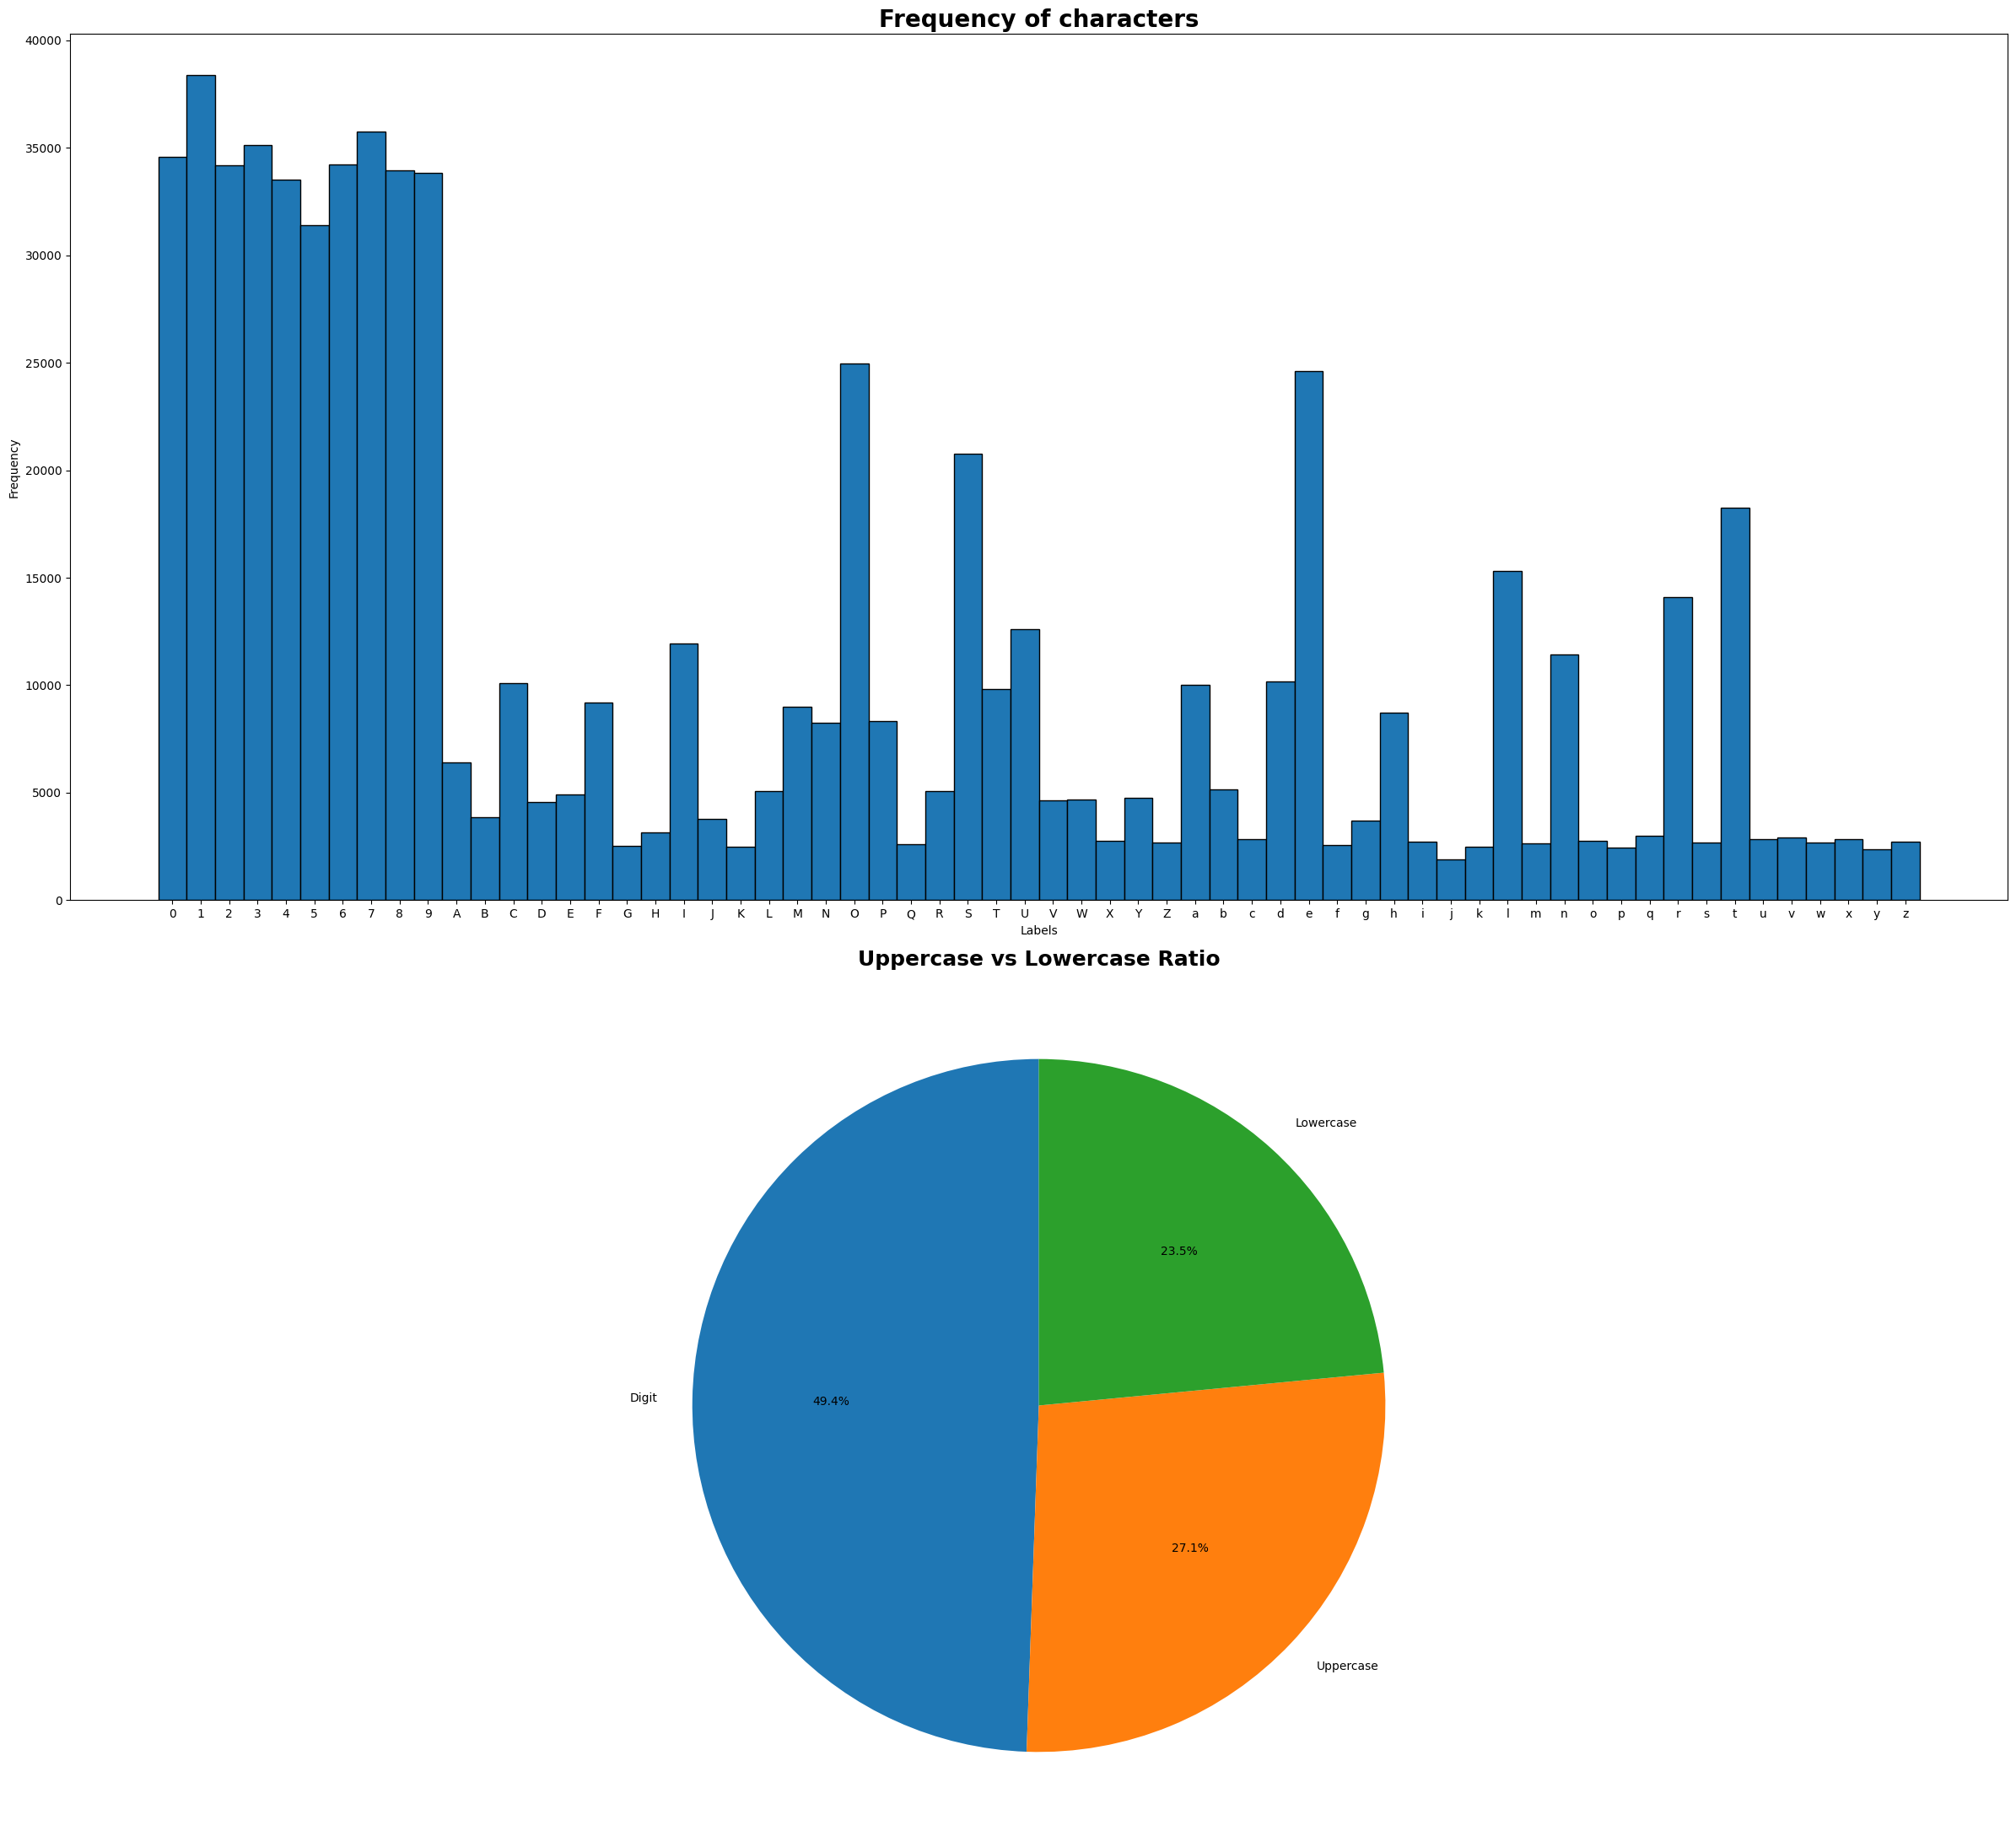

In [25]:
import matplotlib.pyplot as plt
import numpy as np

digit_count = np.sum((train_labels >= 0) & (train_labels <= 9))
upper_count = np.sum((train_labels >= 10) & (train_labels <= 35))
lower_count = np.sum((train_labels >= 36) & (train_labels <= 61))

labels_pie = ['Digit', 'Uppercase', 'Lowercase']
counts = [digit_count ,upper_count, lower_count]

fig, axes = plt.subplots(2, 1, figsize=(24, 22))

bins = np.arange(63) - 0.5
axes[0].hist(train_labels, bins=bins, edgecolor='black')

axes[0].set_xticks(range(62))
axes[0].set_xticklabels(mapping.values())
axes[0].set_xlabel('Labels')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Frequency of characters', fontsize=20, fontweight='bold')

axes[1].pie(
    counts,
    labels=labels_pie,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Uppercase vs Lowercase Ratio', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()


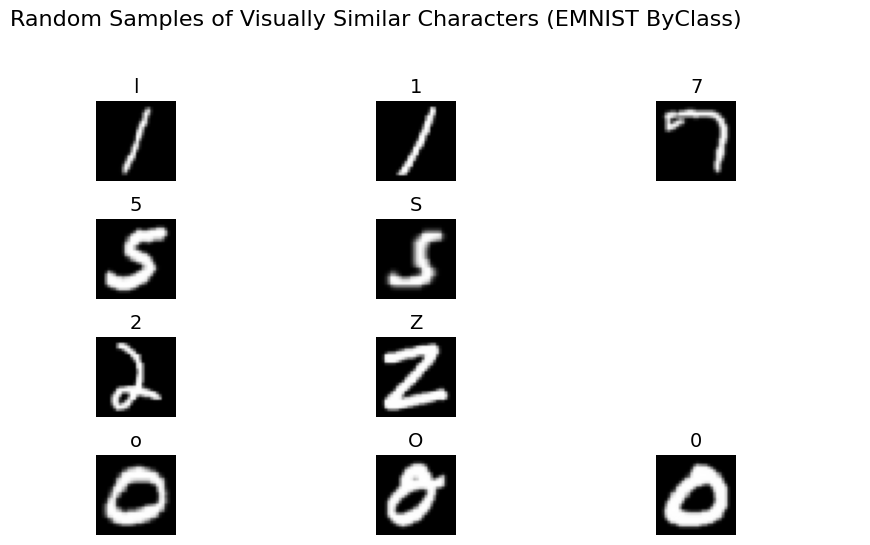

In [11]:
import matplotlib.pyplot as plt
import numpy as np

confusing_groups = [
    ['l', '1', '7'],
    ['5', 'S'],
    ['2', 'Z'],
    ['o', 'O', '0']
]

n_rows = len(confusing_groups)
n_cols = max(len(g) for g in confusing_groups)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(10, 6)
)

for r, group in enumerate(confusing_groups):
    for c in range(n_cols):
        ax = axes[r, c]
        ax.axis('off')

        if c < len(group):
            char = group[c]

            label = [k for k, v in mapping.items() if v == char][0]

            idx = np.where(train_labels == label)[0]
            sample_idx = np.random.choice(idx)

            ax.imshow(train_images[sample_idx], cmap='gray')
            ax.set_title(char, fontsize=14, pad=6)

    axes[r, 0].set_ylabel(
        " – ".join(group),
        rotation=0,
        labelpad=35,
        fontsize=12,
        va='center'
    )

plt.suptitle(
    "Random Samples of Visually Similar Characters (EMNIST ByClass)",
    fontsize=16,
    y=0.95
)

plt.tight_layout(rect=[0.08, 0.05, 1, 0.92])
plt.show()

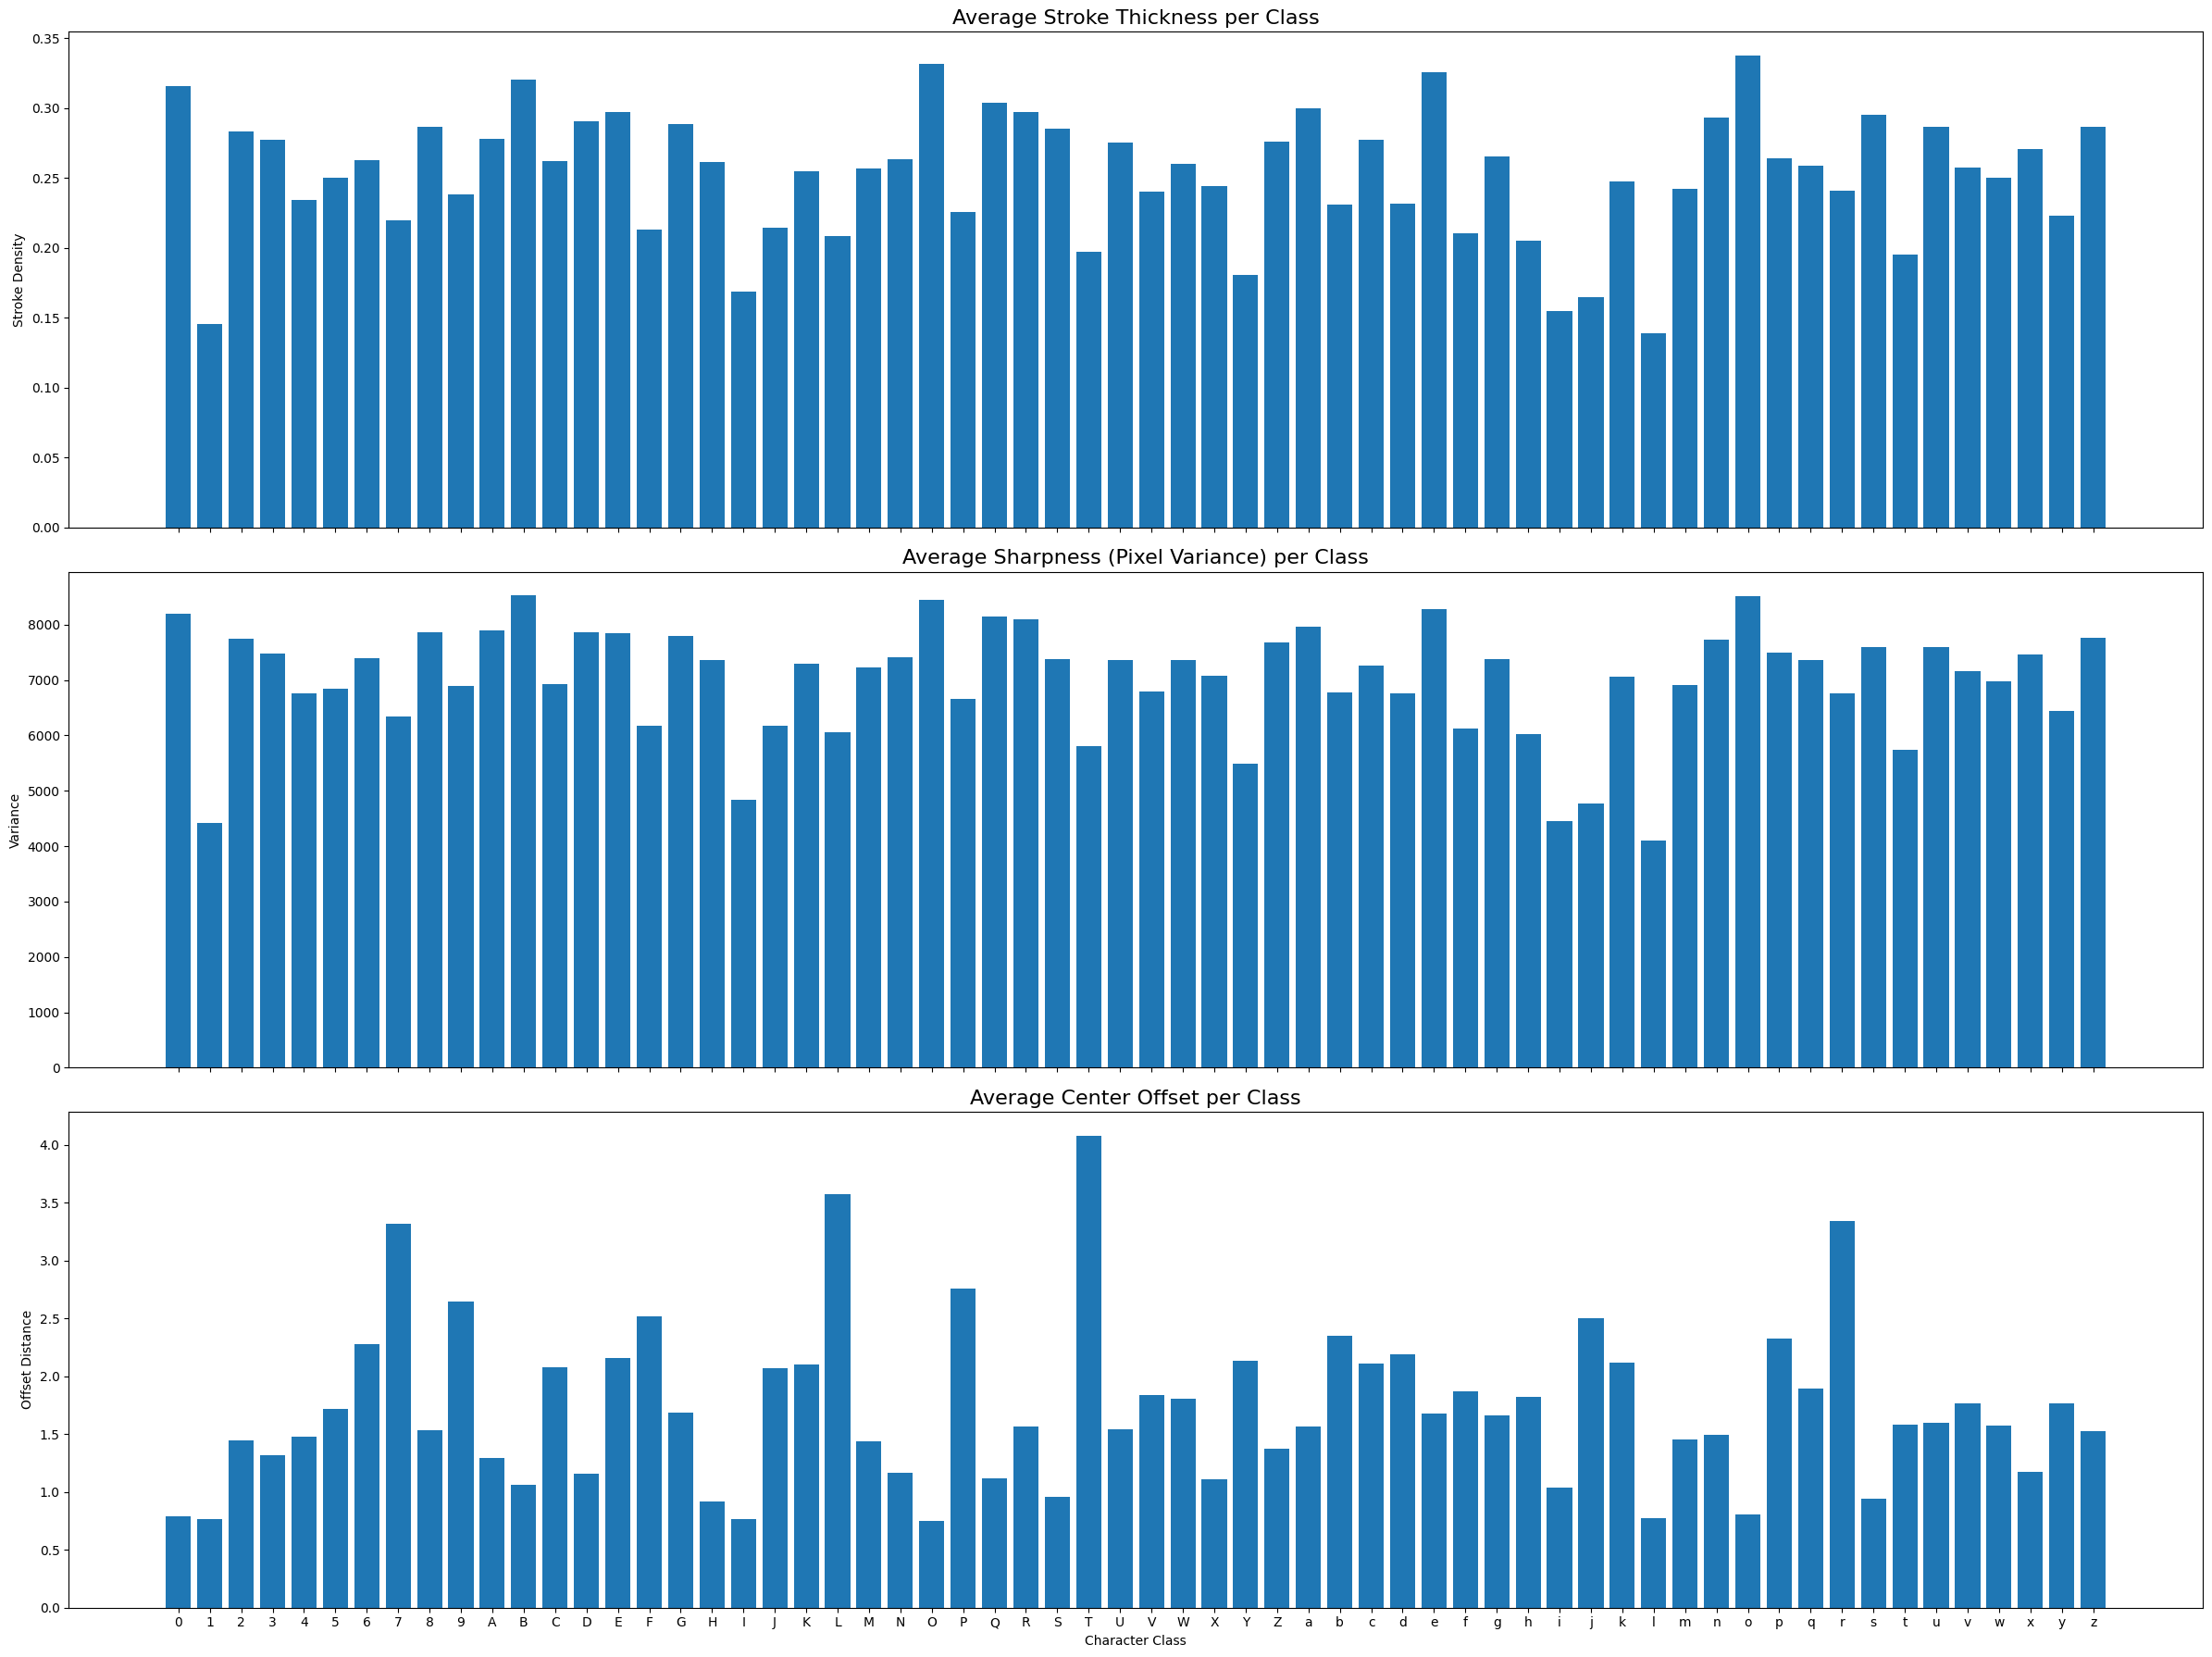

In [6]:
import numpy as np
import matplotlib.pyplot as plt

threshold = 30
stroke_density = (train_images > threshold).mean(axis=(1, 2))

sharpness = train_images.var(axis=(1, 2))

h, w = train_images.shape[1:]
Y, X = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')

weights = train_images + 1e-6
total = weights.sum(axis=(1, 2))

cx = (weights * X).sum(axis=(1, 2)) / total
cy = (weights * Y).sum(axis=(1, 2)) / total

center_offset = np.sqrt((cx - w/2)**2 + (cy - h/2)**2)

num_classes = 62

stroke_mean = []
sharp_mean = []
center_mean = []

for c in range(num_classes):
    idx = train_labels == c
    stroke_mean.append(stroke_density[idx].mean())
    sharp_mean.append(sharpness[idx].mean())
    center_mean.append(center_offset[idx].mean())

fig, axes = plt.subplots(3, 1, figsize=(24, 18), sharex=True)

axes[0].bar(range(num_classes), stroke_mean)
axes[0].set_title('Average Stroke Thickness per Class', fontsize=16)
axes[0].set_ylabel('Stroke Density')

axes[1].bar(range(num_classes), sharp_mean)
axes[1].set_title('Average Sharpness (Pixel Variance) per Class', fontsize=16)
axes[1].set_ylabel('Variance')

axes[2].bar(range(num_classes), center_mean)
axes[2].set_title('Average Center Offset per Class', fontsize=16)
axes[2].set_ylabel('Offset Distance')

axes[2].set_xticks(range(num_classes))
axes[2].set_xticklabels(mapping.values())
axes[2].set_xlabel('Character Class')

plt.tight_layout()
plt.show()

